# Vietnam Traffic Sign Recognition — SVM + HOG Pipeline

Notebook này dùng cho Kaggle để huấn luyện mô hình **SVM** cho bài toán phân loại biển báo giao thông Việt Nam.

**Ý tưởng chính:**

```text
Ảnh biển báo → Resize → Grayscale → HOG feature → StandardScaler → SVM → Evaluation
```

Notebook này chỉ tập trung vào nhánh **SVM**. Nhánh CNN có thể làm riêng sau.

## 1. Import thư viện

Các thư viện chính:
- `opencv-python`: đọc và xử lý ảnh
- `skimage`: trích xuất HOG feature
- `scikit-learn`: huấn luyện SVM và đánh giá kết quả

In [4]:
import os
import random
from pathlib import Path

import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from skimage.feature import hog

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Imports OK")

Imports OK


## 2. Chon duong dan dataset (local)


In [ ]:
CLASSES = ["Cam", "Chidan", "Hieulenh", "Nguyhiem", "Phu"]
ROOT_DIR = Path(".").resolve()

if (ROOT_DIR / "data").is_dir():
    DATA_DIR = ROOT_DIR / "data"
else:
    DATA_DIR = ROOT_DIR.parent / "data"

TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR :", TEST_DIR)
print("Train dir exists:", TRAIN_DIR.exists())
print("Test dir exists :", TEST_DIR.exists())

TRAIN_DIR: /kaggle/input/datasets/hoangnd04/vietnam-traffic-signs/Data/train
TEST_DIR : /kaggle/input/datasets/hoangnd04/vietnam-traffic-signs/Data/test
Train dir exists: True
Test dir exists : True


## 3. Kiểm tra số lượng ảnh theo từng lớp

Bước này giúp bạn phát hiện lỗi đường dẫn hoặc thiếu class.

In [6]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def count_images_by_class(data_dir, classes=CLASSES):
    rows = []
    data_dir = Path(data_dir)
    for cls in classes:
        cls_dir = data_dir / cls
        files = [p for p in cls_dir.rglob("*") if p.suffix.lower() in IMG_EXTS]
        rows.append({"class": cls, "num_images": len(files)})
    return pd.DataFrame(rows)

train_count = count_images_by_class(TRAIN_DIR)
test_count = count_images_by_class(TEST_DIR)

print("Train set:")
display(train_count)

print("Test set:")
display(test_count)

print("Total train:", train_count["num_images"].sum())
print("Total test :", test_count["num_images"].sum())

Train set:


,class,num_images
0,Cam,325
1,Chidan,283
2,Hieulenh,266
3,Nguyhiem,268
4,Phu,202


Test set:


,class,num_images
0,Cam,36
1,Chidan,36
2,Hieulenh,31
3,Nguyhiem,29
4,Phu,23


Total train: 1344
Total test : 155


## 4. Hiển thị ảnh mẫu

Kiểm tra nhanh xem ảnh có được đọc đúng không.

Train set (new): 1075 images
Validation set: 269 images
Test set: 155 images


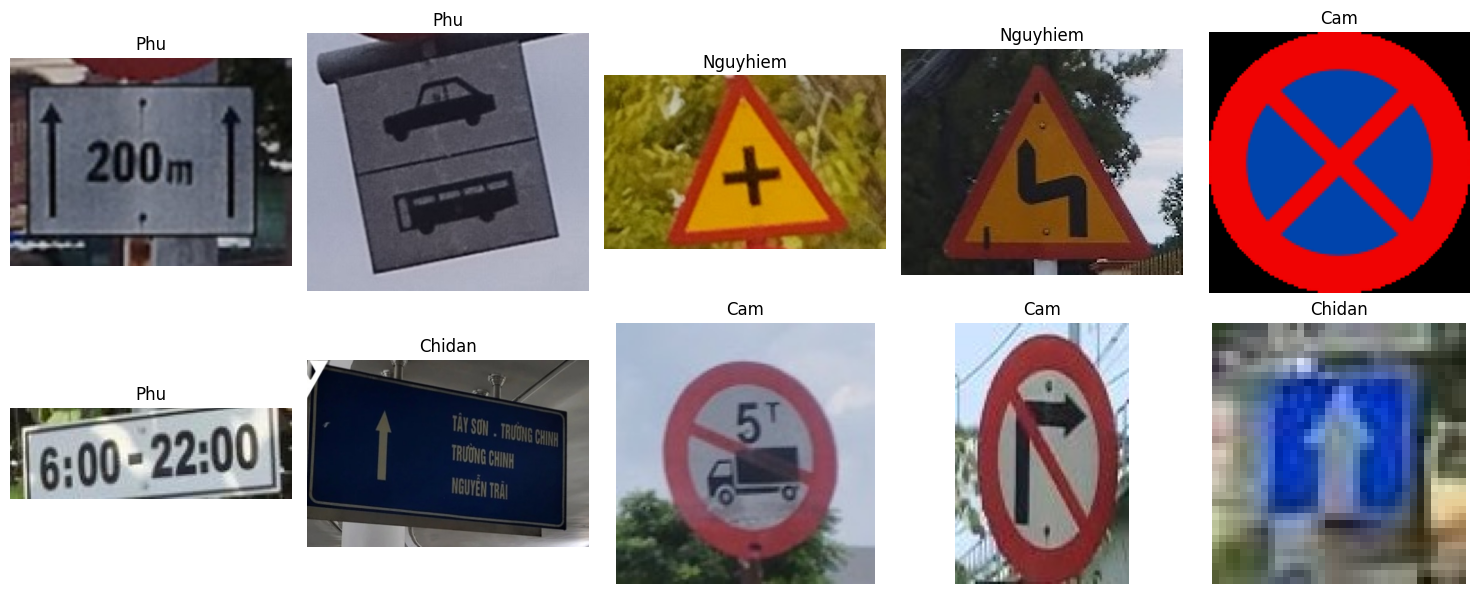

In [7]:
def get_image_paths(data_dir, classes=CLASSES):
    image_paths = []
    labels = []
    data_dir = Path(data_dir)
    for label, cls in enumerate(classes):
        cls_dir = data_dir / cls
        files = sorted([p for p in cls_dir.rglob("*") if p.suffix.lower() in IMG_EXTS])
        image_paths.extend(files)
        labels.extend([label] * len(files))
    return image_paths, np.array(labels)

train_paths, y_train = get_image_paths(TRAIN_DIR)
test_paths, y_test = get_image_paths(TEST_DIR)

# Chia train thành train_new (80%) và validation (20%)
train_paths_new, val_paths, y_train_new, y_val = train_test_split(
    train_paths,
    y_train,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train
)

print(f"Train set (new): {len(train_paths_new)} images")
print(f"Validation set: {len(val_paths)} images")
print(f"Test set: {len(test_paths)} images")

sample_paths = random.sample(train_paths_new, min(10, len(train_paths_new)))

plt.figure(figsize=(15, 6))
for i, path in enumerate(sample_paths):
    img = cv2.imread(str(path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    cls_name = path.parent.name
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(cls_name)
    plt.axis("off")
plt.tight_layout()
plt.show()

## 5. Tiền xử lý ảnh và trích xuất HOG feature

Với SVM, ta không đưa trực tiếp ảnh RGB vào mô hình. Ta trích xuất đặc trưng HOG trước.

Pipeline của mỗi ảnh:

```text
Read image → Resize 64×64 → Grayscale → HOG vector
```

Thông số HOG đề xuất:
- `orientations=9`
- `pixels_per_cell=(8, 8)`
- `cells_per_block=(2, 2)`
- `block_norm="L2-Hys"`

In [8]:
IMG_SIZE = (64, 64)  # Có thể thử (128, 128) sau nếu muốn


def read_preprocess_image(path, img_size=IMG_SIZE):
    """Read image, resize, convert to grayscale."""
    img = cv2.imread(str(path))
    if img is None:
        raise ValueError(f"Cannot read image: {path}")
    img = cv2.resize(img, img_size)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return gray


def extract_hog_feature(gray_img):
    feature = hog(
        gray_img,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        transform_sqrt=True,
        feature_vector=True
    )
    return feature


def build_hog_dataset(image_paths):
    features = []
    valid_paths = []

    for path in tqdm(image_paths, desc="Extracting HOG"):
        try:
            gray = read_preprocess_image(path)
            feat = extract_hog_feature(gray)
            features.append(feat)
            valid_paths.append(path)
        except Exception as e:
            print("Skip:", path, "|", e)

    return np.array(features, dtype=np.float32), valid_paths

X_train_hog, train_valid_paths = build_hog_dataset(train_paths_new)
X_val_hog, val_valid_paths = build_hog_dataset(val_paths)
X_test_hog, test_valid_paths = build_hog_dataset(test_paths)

print("X_train_hog shape:", X_train_hog.shape)
print("X_val_hog shape  :", X_val_hog.shape)
print("X_test_hog shape :", X_test_hog.shape)
print("y_train_new shape:", y_train_new.shape)
print("y_val shape      :", y_val.shape)
print("y_test shape     :", y_test.shape)

Extracting HOG:   0%|          | 0/1075 [00:00<?, ?it/s]

Extracting HOG:   0%|          | 0/269 [00:00<?, ?it/s]

Extracting HOG:   0%|          | 0/155 [00:00<?, ?it/s]

X_train_hog shape: (1075, 1764)
X_val_hog shape  : (269, 1764)
X_test_hog shape : (155, 1764)
y_train_new shape: (1075,)
y_val shape      : (269,)
y_test shape     : (155,)


## 6. Visualize HOG của một ảnh mẫu

Cell này dùng để đưa vào báo cáo nếu cần minh họa HOG feature.

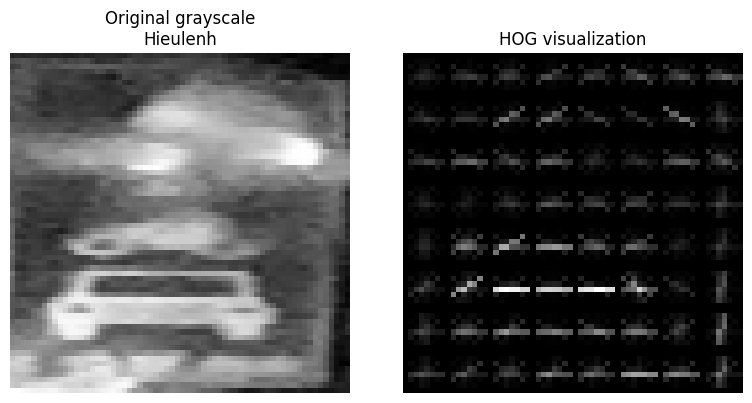

In [9]:
from skimage.feature import hog

sample_path = train_paths_new[0]
gray = read_preprocess_image(sample_path)

hog_feature, hog_image = hog(
    gray,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    transform_sqrt=True,
    visualize=True,
    feature_vector=True
)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title(f"Original grayscale\n{sample_path.parent.name}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hog_image, cmap="gray")
plt.title("HOG visualization")
plt.axis("off")

plt.tight_layout()
plt.show()

## 7. Train SVM model

Ta dùng `Pipeline` gồm:

```text
StandardScaler → SVC
```

Lưu ý: `StandardScaler` chỉ được fit trên train set. Khi dùng `Pipeline`, scikit-learn tự xử lý đúng quy trình này.

In [10]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=10,
        gamma="scale",
        class_weight="balanced",
        probability=False,
        random_state=SEED
    ))
])

svm_model.fit(X_train_hog, y_train_new)
print("SVM training completed")

SVM training completed


## 8. Đánh giá mô hình trên test set

Các độ đo cần đưa vào báo cáo:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

In [11]:
y_val_pred = svm_model.predict(X_val_hog)
val_acc = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_acc:.4f}")
print("Validation Classification Report:")
print(classification_report(y_val, y_val_pred, target_names=CLASSES, digits=4))
print("-" * 50)

y_pred = svm_model.predict(X_test_hog)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}")
print("Test Classification Report:")
print(classification_report(y_test, y_pred, target_names=CLASSES, digits=4))

Validation Accuracy: 0.8513
Validation Classification Report:
              precision    recall  f1-score   support

         Cam     0.9206    0.8923    0.9062        65
      Chidan     0.8246    0.8246    0.8246        57
    Hieulenh     0.7636    0.7925    0.7778        53
    Nguyhiem     1.0000    0.9444    0.9714        54
         Phu     0.7209    0.7750    0.7470        40

    accuracy                         0.8513       269
   macro avg     0.8460    0.8458    0.8454       269
weighted avg     0.8556    0.8513    0.8530       269

--------------------------------------------------
Test Accuracy: 0.8387
Test Classification Report:
              precision    recall  f1-score   support

         Cam     0.9412    0.8889    0.9143        36
      Chidan     0.8333    0.6944    0.7576        36
    Hieulenh     0.7576    0.8065    0.7812        31
    Nguyhiem     1.0000    1.0000    1.0000        29
         Phu     0.6552    0.8261    0.7308        23

    accuracy          

## 9. Confusion Matrix

Dùng để xem mô hình hay nhầm lớp nào với lớp nào.

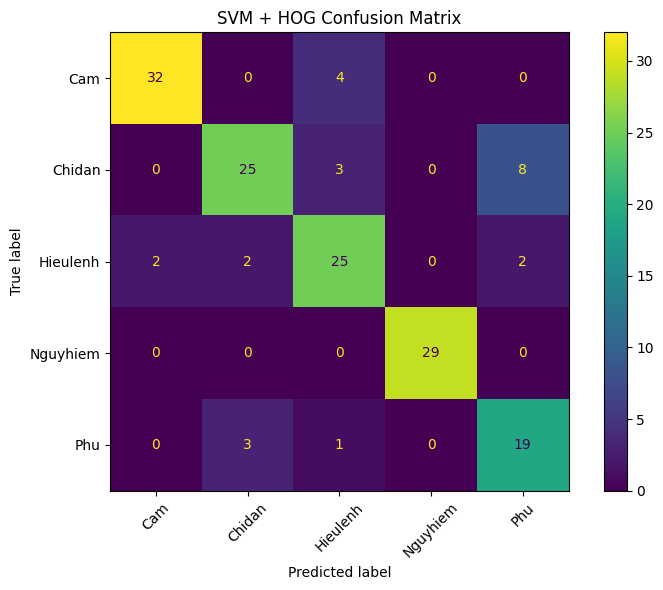

In [12]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(ax=ax, xticks_rotation=45, values_format="d")
plt.title("SVM + HOG Confusion Matrix")
plt.tight_layout()
plt.show()

## 10. Luu ket qua va mo hinh

Sau khi chay xong, mo hinh se duoc luu vao `svm/models/svm_hog_model.joblib`.

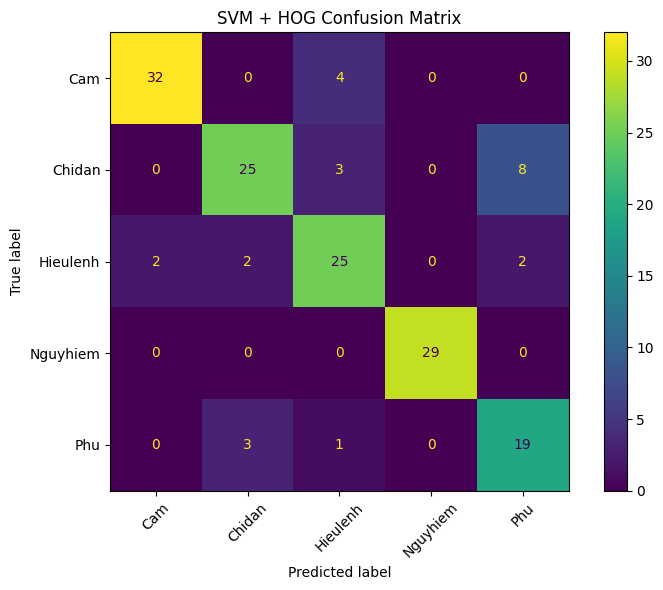

Saved model to: /kaggle/working/svm_hog_model.joblib
Saved report to: /kaggle/working/svm_classification_report.txt
Saved confusion matrix to: /kaggle/working/svm_confusion_matrix.png


In [ ]:
ROOT_DIR = Path(".").resolve()
SVM_DIR = ROOT_DIR / "svm"
if not SVM_DIR.is_dir():
    SVM_DIR = ROOT_DIR

MODELS_DIR = SVM_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODELS_DIR / "svm_hog_model.joblib"
report_path = SVM_DIR / "svm_classification_report.txt"
cm_path = SVM_DIR / "svm_confusion_matrix.png"

joblib.dump(svm_model, model_path)

report = classification_report(y_test, y_pred, target_names=CLASSES, digits=4)
with open(report_path, "w", encoding="utf-8") as f:
    f.write(f"Test Accuracy: {acc:.4f}\\n\\n")
    f.write(report)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(ax=ax, xticks_rotation=45, values_format="d")
plt.title("SVM + HOG Confusion Matrix")
plt.tight_layout()
plt.savefig(cm_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved model to:", model_path)
print("Saved report to:", report_path)
print("Saved confusion matrix to:", cm_path)

## 11. Xem các ảnh dự đoán sai

Phần này rất hữu ích để viết nhận xét trong báo cáo.

Number of wrong predictions: 25


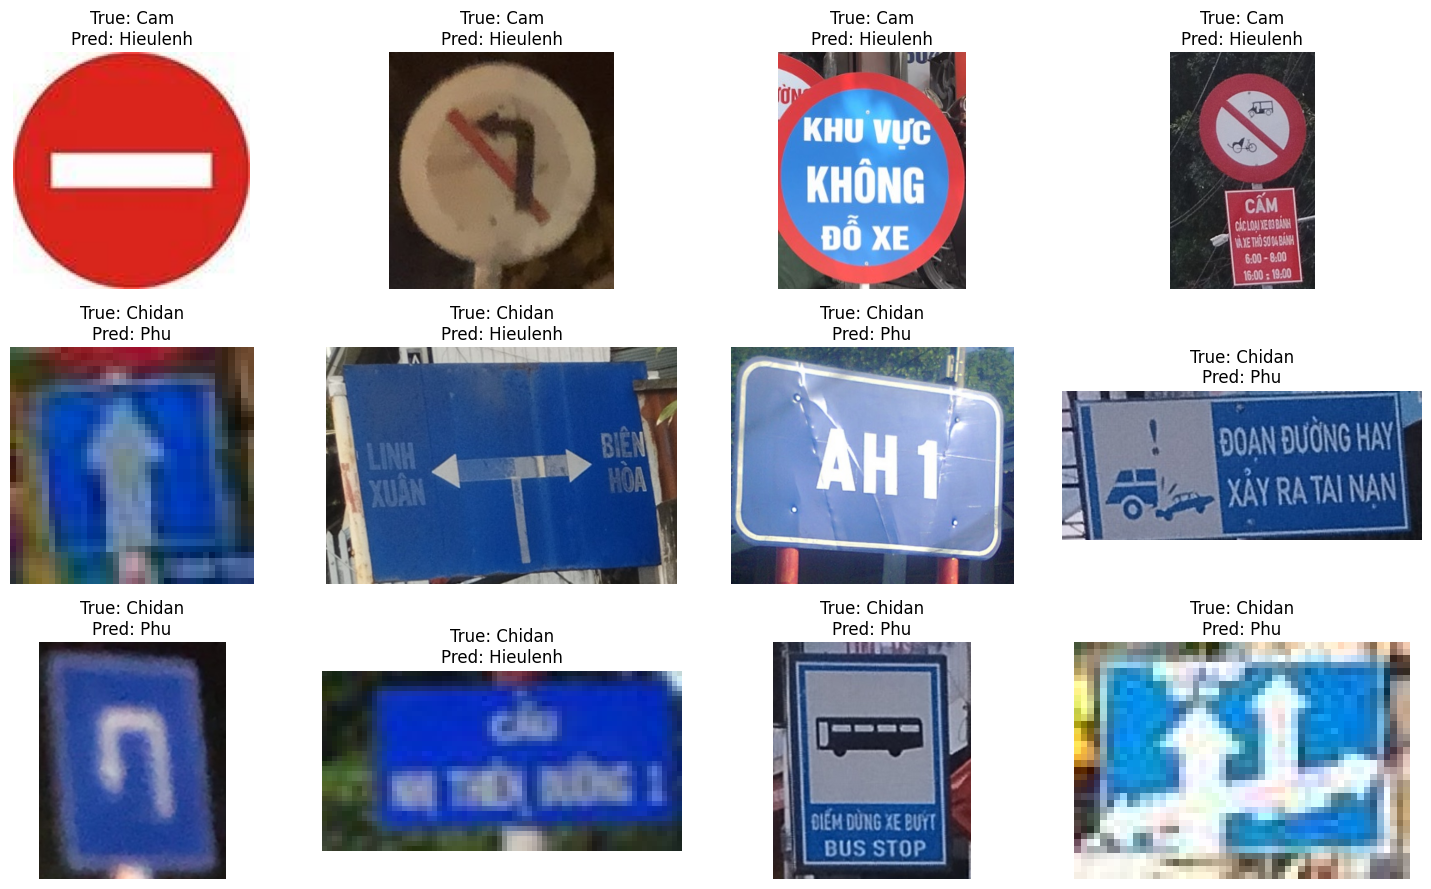

In [14]:
wrong_indices = np.where(y_test != y_pred)[0]
print("Number of wrong predictions:", len(wrong_indices))

if len(wrong_indices) > 0:
    show_n = min(12, len(wrong_indices))
    selected = wrong_indices[:show_n]

    plt.figure(figsize=(15, 9))
    for i, idx in enumerate(selected):
        path = test_paths[idx]
        img = cv2.imread(str(path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        true_name = CLASSES[y_test[idx]]
        pred_name = CLASSES[y_pred[idx]]

        plt.subplot(3, 4, i + 1)
        plt.imshow(img)
        plt.title(f"True: {true_name}\nPred: {pred_name}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Không có ảnh dự đoán sai trong test set.")

## 12. Predict thử một ảnh bất kỳ

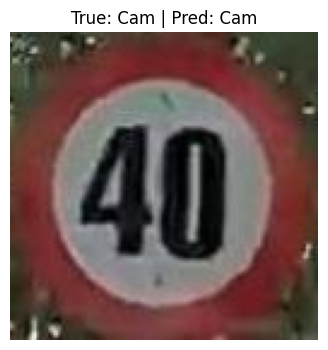

In [15]:
def predict_image(image_path, model=svm_model):
    gray = read_preprocess_image(image_path)
    feat = extract_hog_feature(gray).reshape(1, -1)
    pred = model.predict(feat)[0]
    return CLASSES[pred]

image_path = test_paths[0]
pred_class = predict_image(image_path)
true_class = image_path.parent.name

img = cv2.imread(str(image_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title(f"True: {true_class} | Pred: {pred_class}")
plt.axis("off")
plt.show()

## 13. Optional: Tuning tham số SVM

Chạy cell này nếu bạn muốn thử cải thiện kết quả. Có thể mất thời gian hơn.

Nếu chỉ cần demo đồ án, bạn có thể bỏ qua phần này.

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best params: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV macro F1: 0.8477787636436419
Best model test accuracy: 0.8387096774193549
              precision    recall  f1-score   support

         Cam     0.9412    0.8889    0.9143        36
      Chidan     0.8333    0.6944    0.7576        36
    Hieulenh     0.7576    0.8065    0.7812        31
    Nguyhiem     1.0000    1.0000    1.0000        29
         Phu     0.6552    0.8261    0.7308        23

    accuracy                         0.8387       155
   macro avg     0.8375    0.8432    0.8368       155
weighted avg     0.8480    0.8387    0.8401       155



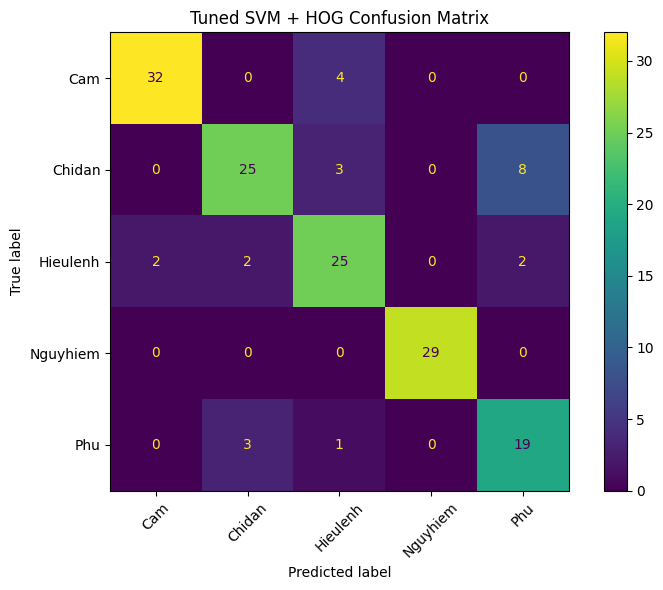

[CV] END ......svm__C=0.1, svm__gamma=scale, svm__kernel=rbf; total time=   1.9s
[CV] END ......svm__C=0.1, svm__gamma=0.001, svm__kernel=rbf; total time=   2.2s
[CV] END ........svm__C=0.1, svm__gamma=0.1, svm__kernel=rbf; total time=   2.0s
[CV] END ........svm__C=1, svm__gamma=scale, svm__kernel=rbf; total time=   1.7s
[CV] END .........svm__C=1, svm__gamma=0.01, svm__kernel=rbf; total time=   2.1s
[CV] END ..........svm__C=1, svm__gamma=0.1, svm__kernel=rbf; total time=   1.9s
[CV] END .......svm__C=10, svm__gamma=scale, svm__kernel=rbf; total time=   1.7s
[CV] END ........svm__C=10, svm__gamma=0.01, svm__kernel=rbf; total time=   2.0s
[CV] END .........svm__C=10, svm__gamma=0.1, svm__kernel=rbf; total time=   2.0s
[CV] END ......svm__C=100, svm__gamma=scale, svm__kernel=rbf; total time=   1.8s
[CV] END .......svm__C=100, svm__gamma=0.01, svm__kernel=rbf; total time=   2.1s
[CV] END ......svm__C=0.1, svm__gamma=0.001, svm__kernel=rbf; total time=   1.8s
[CV] END .......svm__C=0.1, 

In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

param_grid = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", 0.001, 0.01, 0.1],
    "svm__kernel": ["rbf"]
}

grid = GridSearchCV(
    svm_model,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train_hog, y_train_new)

print("Best params:", grid.best_params_)
print("Best CV macro F1:", grid.best_score_)

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_hog)

best_acc = accuracy_score(y_test, y_pred_best)
best_cm = confusion_matrix(y_test, y_pred_best)

print("Best model test accuracy:", best_acc)
print(classification_report(y_test, y_pred_best, target_names=CLASSES, digits=4))

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=best_cm, display_labels=CLASSES)
disp.plot(ax=ax, xticks_rotation=45, values_format="d")
plt.title("Tuned SVM + HOG Confusion Matrix")
plt.tight_layout()
plt.show()

## 14. Đoạn mô tả có thể đưa vào báo cáo

Trong phương pháp SVM, ảnh đầu vào được resize về kích thước 64×64 và chuyển sang ảnh xám. Sau đó, nhóm sử dụng Histogram of Oriented Gradients (HOG) để trích xuất đặc trưng hình dạng và cạnh của biển báo. Các vector đặc trưng HOG được chuẩn hóa bằng StandardScaler và đưa vào bộ phân loại Support Vector Machine với kernel RBF. Mô hình được huấn luyện trên tập train và đánh giá trên tập test thông qua Accuracy, Precision, Recall, F1-score và Confusion Matrix.